# Set up workspace

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import sys
sys.path.append('/glade/u/home/czarakas/coupled_PPE/code/utils')

from load_gridcell_areas import *
from plotting_settings import *

# Load data

In [4]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/EOFs/'
dir_input_means='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'

In [5]:
var='PRECT'
eofs_P=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_EOFs.nc')
pcs_P=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_PCs.nc')
var_explained_P=xr.open_dataset(dir_input+'EOFanalysis_calculated_PREC_FROM_ATM_coupled_varianceFraction.nc')

pvals_P=xr.open_dataset(dir_input_means+'pval_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')#['pval']
ds_array_P=xr.open_dataset(dir_input_means+'delta_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')
ds_ref_P=xr.open_dataset(dir_input_means+'ref_calculated_PREC_FROM_ATM_Annual_mean_coupled.nc')#['calculated_PREC_FROM_ATM']

In [6]:
var='TSKIN'
eofs_T=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_EOFs.nc')
pcs_T=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_PCs.nc')
var_explained_T=xr.open_dataset(dir_input+'EOFanalysis_TSKIN_coupled_varianceFraction.nc')

pvals_T=xr.open_dataset(dir_input_means+'pval_TSKIN_Annual_mean_coupled.nc')#['pval']
ds_array_T=xr.open_dataset(dir_input_means+'delta_TSKIN_Annual_mean_coupled.nc')
ds_ref_T=xr.open_dataset(dir_input_means+'ref_TSKIN_Annual_mean_coupled.nc')#['calculated_PREC_FROM_ATM']

In [7]:
dir_input='/glade/work/czarakas/coupled_PPE/data/data_for_figures/annual_means/'
SH=xr.open_dataset(dir_input+'FSH_Annual_mean_offline.nc').FSH
LH=xr.open_dataset(dir_input+'EFLX_LH_TOT_Annual_mean_offline.nc').EFLX_LH_TOT

SH_ref=xr.open_dataset(dir_input+'ref_FSH_Annual_mean_offline.nc').FSH
LH_ref=xr.open_dataset(dir_input+'ref_EFLX_LH_TOT_Annual_mean_offline.nc').EFLX_LH_TOT

# Calculate land surface properties

In [8]:
LH_global=(LH*landweights2).sum(dim=['lat','lon'])
SH_global=(SH*landweights2).sum(dim=['lat','lon'])
EF_global=LH_global/(LH_global+SH_global)

LH_global_ref=(LH_ref*landweights2).sum(dim=['lat','lon'])
SH_global_ref=(SH_ref*landweights2).sum(dim=['lat','lon'])
EF_global_ref=LH_global_ref/(LH_global_ref+SH_global_ref)

EF_global_delta=EF_global-EF_global_ref

In [9]:
X = np.arange(1000).reshape(-1,1)
np.shape(X)

(1000, 1)

In [10]:
np.shape(EF_global_delta.values)

(36,)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False)


#lr_fi_false = LinearRegression(fit_intercept=False)
# x = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 20.0, 40.0, 60.0, 80.0]
# y = [0.50505332505407008, 1.1207373784533172, 2.1981844719020001, 3.1746209003398689, 4.2905482471260044, 6.2816226678076958, 11.073788414382639, 23.248479770546009, 32.120462301367183, 44.036117671229206, 54.009003143831116, 102.7077685684846, 185.72880217806673, 256.12183145545811, 301.97120103079675]
#slope, intercept = linear_regression(x, y, proportional=True)

# Make summary figure

In [12]:
mode_multiplier_T=-2*pcs_T.pcs.std(dim='time')
mode_multiplier_P=2*pcs_P.pcs.std(dim='time')

0.7530368193350253
0.8372835351485094


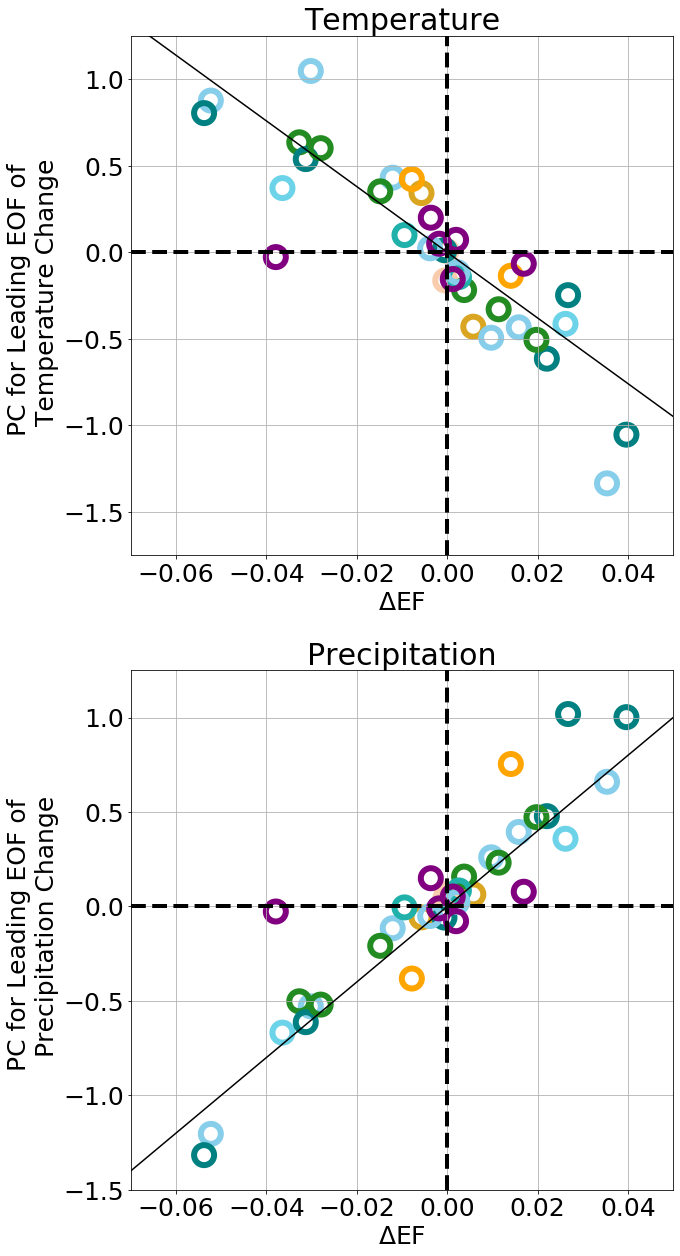

In [14]:
plt.figure(figsize=(10,18))
plt.rcParams.update({'font.size': 25})

plt.subplot(2,1,1)
plt.title('Temperature')
x=EF_global_delta.values.reshape(-1,1)
y=pcs_T.pcs[:,0]/mode_multiplier_T[0]

plt.axvline(x=0,linestyle='--',color='k',linewidth=4)
plt.axhline(y=0,linestyle='--',color='k',linewidth=4)
plt.scatter(x,
            y, s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)

model.fit(x, y)
m=model.coef_
b=model.intercept_
yhat=(m*np.array([-0.1,0.1])+b)
print(model.score(x,y))
plt.plot(np.array([-0.1,0.1]),yhat,'-k')
plt.xlim([-0.07,0.05])
plt.ylim([-1.75,1.25])

plt.grid()
plt.xlabel('$\Delta$EF')
plt.ylabel('PC for Leading EOF of \n Temperature Change')


plt.subplot(2,1,2)
plt.title('Precipitation')
x=EF_global_delta.values.reshape(-1,1)
y=pcs_P.pcs[:,0]/mode_multiplier_P[0]

plt.axvline(x=0,linestyle='--',color='k',linewidth=4)
plt.axhline(y=0,linestyle='--',color='k',linewidth=4)
plt.scatter(x,
            y, s=400, 
            edgecolors=colors,facecolors='none',linewidth=6)
plt.grid()

model.fit(x, y)
m=model.coef_
b=model.intercept_
print(model.score(x,y))
yhat=(m*np.array([-0.1,0.1])+b)
plt.plot(np.array([-0.1,0.1]),yhat,'-k')
plt.xlim([-0.07,0.05])
plt.ylim([-1.5,1.25])
plt.xlabel('$\Delta$EF')
plt.ylabel('PC for Leading EOF of \n Precipitation Change')
plt.tight_layout()
plt.savefig('../Figures/Figure_S_EOF_vs_Temperature_and_Precipitation.pdf')